## ===========================================================
## FASE 1: CARICAMENTO E PREPROCESSING
## ===========================================================

In [32]:
import pandas as pd #Serve per i DataFrame
import numpy as np #Serve per vettori e matrici
import re #Serve per pulizia stringhe
import matplotlib.pyplot as plt #Serve per i grafici
import seaborn as sns #Serve per migliorare la grafica e la gestione dei DataFrame

import nltk                         
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

my_number = 20 #Serve per riproducibilità
top_words = 20 #Serve per le migliori N parole
lenght = 150 #Serve per la lunghezza delle recensioni

print("Librerie importate correttamente")

Librerie importate correttamente


In [33]:
print("--- IMPORT DEL DATASET ---")
df = pd.read_csv("winemag-data-130k-v2.csv", index_col = 0) #Usa la prima colonna come indice invece che crearne un'altra
print(f"\nDataset caricato correttamente con {len(df)} recensioni")
df.head()

--- IMPORT DEL DATASET ---

Dataset caricato correttamente con 129971 recensioni


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [34]:
print("--- PULIZIA DEL DATASET ---")

df = df.drop_duplicates(subset = "description") #Elimina righe con descrizione identica
df = df.dropna(subset = ["description", "points"]) #Elimina righe con dati mancanti 

print(f"\nDataset pulito e pronto con {len(df)} recensioni valide.")
df.describe()

--- PULIZIA DEL DATASET ---

Dataset pulito e pronto con 119955 recensioni valide.


,points,price
count,119955.000000,111567.000000
mean,88.442291,35.620542
std,3.093029,42.107158
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


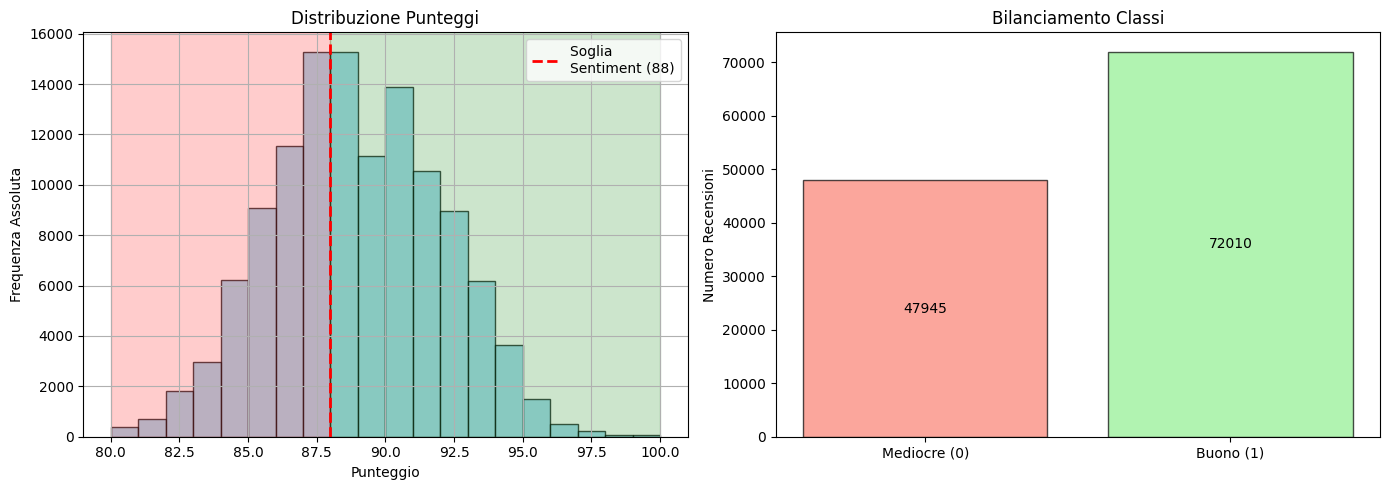

In [35]:
df["Sentiment"] = np.where(df["points"] >= 88, 1, 0)  #Scegliamo 88 poichè è la Mediana

plt.figure(figsize = (14, 5))

#Istogramma Punteggi
plt.subplot(1, 2, 1)
df["points"].hist(bins = 20, color = "skyblue", edgecolor = "black", alpha = 0.7) #Crea 20 barre
plt.title("Distribuzione Punteggi")
plt.xlabel("Punteggio")
plt.ylabel("Frequenza Assoluta")

#Linea soglia  e aree colorate
plt.axvline(x = 88, color = "red", linestyle = "--", linewidth = 2, label = "Soglia \nSentiment (88)") #Disegna la linea verticale rossa tratteggiata
plt.axvspan(80, 88, alpha = 0.2, color = "red") #Rosso trasparente
plt.axvspan(88, 100, alpha = 0.2, color = "green") #Verde trasparente
plt.legend()

#Bilanciamento Classi
plt.subplot(1, 2, 2)
sentiment_counts = df["Sentiment"].value_counts().sort_index() #Conta il numero di 0 ed 1 presenti e poi ordina
bars = plt.bar(["Mediocre (0)", "Buono (1)"], sentiment_counts, color = ["salmon", "lightgreen"], edgecolor = "black", alpha = 0.7)
plt.title("Bilanciamento Classi")
plt.ylabel("Numero Recensioni")
for c in plt.gca().containers: plt.gca().bar_label(c, label_type = "center") #Mostra i valori sulle barre

plt.tight_layout()
plt.show()

In [36]:
print("--- IDENTIFICAZIONE VINI SICILIANI ---")

df["Is_Sicilian"] = df["province"].str.contains("Sicily", na = False).astype(int) #Identifica vini siciliani e converte T/F in 1/0

n_siciliani = df["Is_Sicilian"].sum()
n_mondo = len(df) - n_siciliani

print(f"\nVini Siciliani:\t\t{n_siciliani} su {len(df)} ({n_siciliani / len(df) * 100:.2f}%)")
print(f"Vini resto del Mondo:\t{n_mondo} su {len(df)} ({n_mondo / len(df) * 100:.2f}%)")

--- IDENTIFICAZIONE VINI SICILIANI ---

Vini Siciliani:		1631 su 119955 (1.36%)
Vini resto del Mondo:	118324 su 119955 (98.64%)


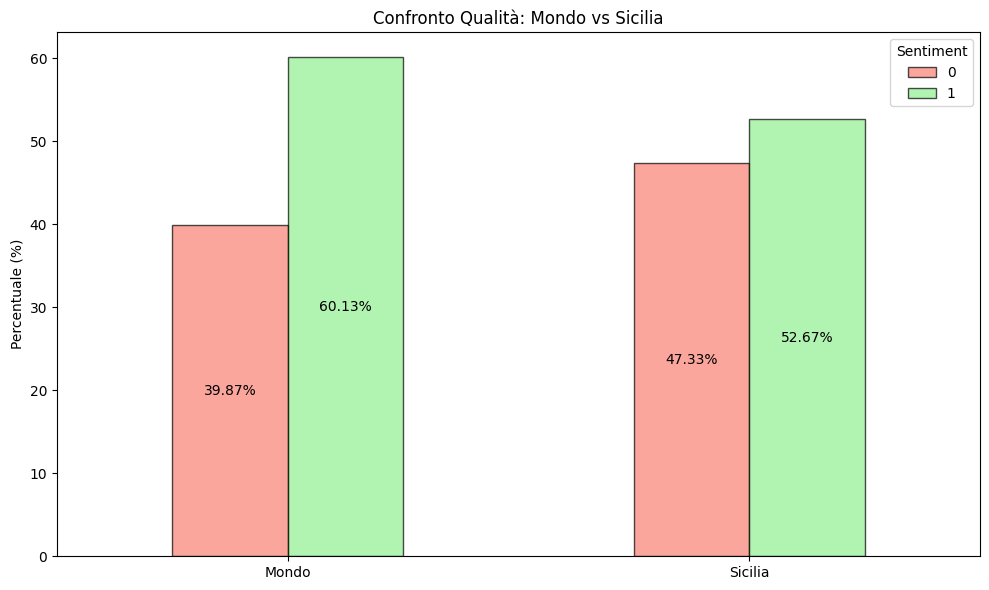

In [37]:
confronto = pd.crosstab(df["Is_Sicilian"], df["Sentiment"], normalize = "index") * 100 #Incrocia le due variabili e calcola le percentuali
confronto.plot(kind = "bar", figsize = (10, 6), color = ["salmon", "lightgreen"], edgecolor = "black", alpha = 0.7)

plt.title("Confronto Qualità: Mondo vs Sicilia")
plt.ylabel("Percentuale (%)")
plt.xlabel("")
plt.xticks([0, 1], ["Mondo", "Sicilia"], rotation = 0)
for c in plt.gca().containers: plt.gca().bar_label(c, fmt = "%.2f%%", label_type = "center") #Mostra i valori sulle barre in percentuale

plt.tight_layout()
plt.show()

In [38]:
print("--- PREPROCESSING DEL TESTO ---")

stop_words = set(stopwords.words("english")) #Carica le stopword e le converte in un set (più veloce rispetto a lista)

def preprocess_text(text):
    text = re.sub(r"[^a-z\s]", "", text.lower()) #Converte in minuscolo e sostituisce con "" qualsiasi carattere diverso da minuscolo o spazio, rimuovendo numeri e punteggiatura
    return " ".join([w for w in text.split() if w not in stop_words and len(w) > 2])  #Divide in parole singole, filtra le stopwords o le parole corte (len <=2) e ricostruisce la stringa

print("\nTest di pulizia su una recensione a caso:")
test_idx = df.index[my_number]
raw = df.loc[test_idx, "description"]
clean = preprocess_text(raw)

print(f"ORIGINALE:\t{raw[:lenght]}...")
print(f"PULITO:\t\t{clean[:lenght]}...")

print(f"\nAvvio pulizia di {len(df)} recensioni")
df["description_clean"] = df["description"].apply(preprocess_text)
print("Pulizia completata!")

--- PREPROCESSING DEL TESTO ---

Test di pulizia su una recensione a caso:
ORIGINALE:	Ripe aromas of dark berries mingle with ample notes of black pepper, toasted vanilla and dusty tobacco. The palate is oak-driven in nature, but notes ...
PULITO:		ripe aromas dark berries mingle ample notes black pepper toasted vanilla dusty tobacco palate oakdriven nature notes tart red currant shine offering b...

Avvio pulizia di 119955 recensioni
Pulizia completata!


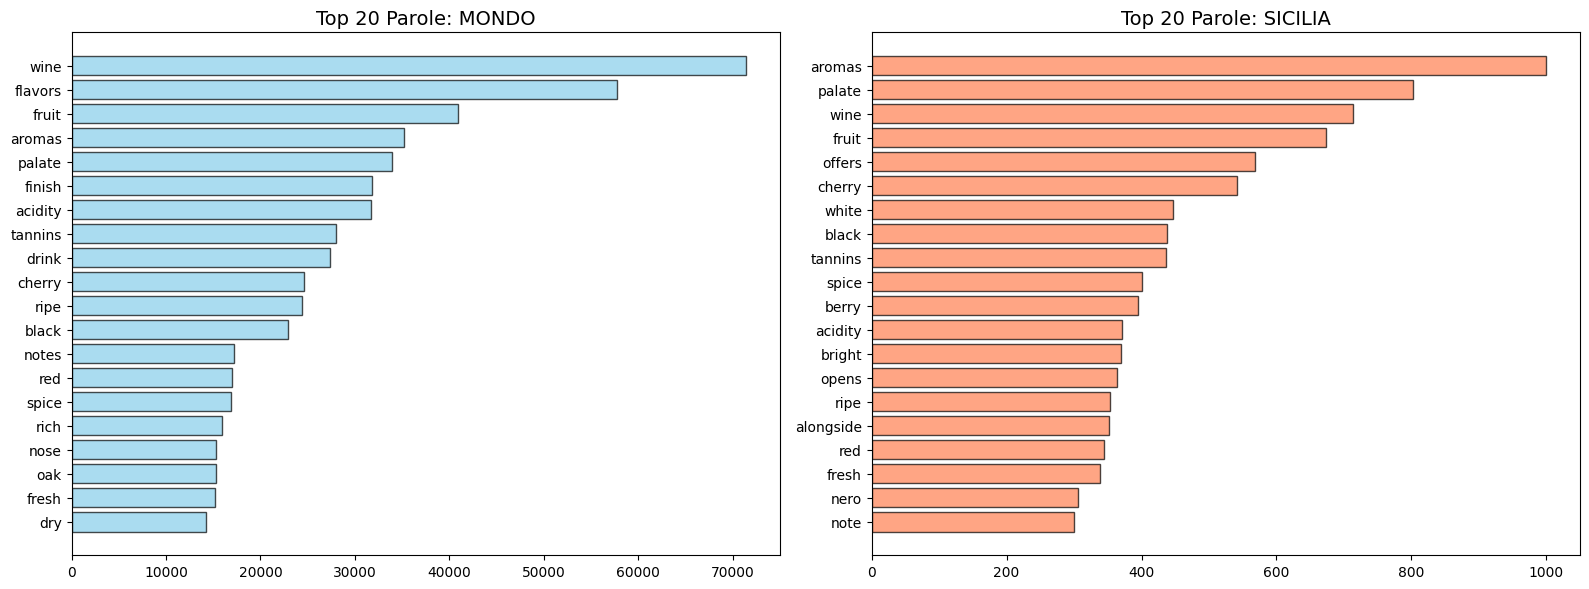

In [39]:
def get_top_words(text_series, value):
    text = " ".join(text_series) #Unisce tutte le recensioni in un unica stringa
    words = text.split() #Divide in singole parole
    return pd.Series(words).value_counts().head(value) #Crea una serie, conta e restituisce le top parole

df_sicily = df[df["Is_Sicilian"] == 1]
df_world = df[df["Is_Sicilian"] == 0]
top_world = get_top_words(df_world["description_clean"], top_words)
top_sicily = get_top_words(df_sicily["description_clean"], top_words)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

#Grafico Mondo
axes[0].barh(top_world.index, top_world.values, color = "skyblue", edgecolor = "black", alpha = 0.7)
axes[0].invert_yaxis()
axes[0].set_title(f"Top {top_words} Parole: MONDO", fontsize = 14)

#Grafico Sicilia
axes[1].barh(top_sicily.index, top_sicily.values, color = "coral", edgecolor = "black", alpha = 0.7)
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_words} Parole: SICILIA", fontsize = 14)

plt.tight_layout()
plt.show()

In [40]:
print("--- COSA RENDE UNICI I VINI SICILIANI? ---")

set_sicilia = set(top_sicily.index)
set_mondo = set(top_world.index)
uniche_sicilia = set_sicilia - set_mondo

if uniche_sicilia: print(f"\nParole distintive trovate in Top {top_words}:\n{", ".join(sorted(uniche_sicilia))}.")
else: print(f"Il lessico è molto simile al resto del mondo (nessuna parola unica nelle Top {top_words}).")

--- COSA RENDE UNICI I VINI SICILIANI? ---

Parole distintive trovate in Top 20:
alongside, berry, bright, nero, note, offers, opens, white.


## ===========================================================
## FASE 2: VETTORIZZAZIONE TF - IDF E TRAINING MODELLI (NB e LR)
## ===========================================================

In [41]:
print("--- SPLIT IN TRAIN E TEST SET (80 / 20) ---")

X = df["description_clean"] #Feature
y = df["Sentiment"] #Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    random_state = my_number,
)

print(f"\nTraining set: {len(X_train)} recensioni")
print(f"Test set:     {len(X_test)} recensioni")

--- SPLIT IN TRAIN E TEST SET (80 / 20) ---

Training set: 95964 recensioni
Test set:     23991 recensioni


In [42]:
print("\n--- SUDDIVISIONE DELLE FEATURE POSITIVE NEI SET ---")
print(f"\nTraining: {y_train.mean():.2%}")
print(f"Test    : {y_test.mean():.2%}")


--- SUDDIVISIONE DELLE FEATURE POSITIVE NEI SET ---

Training: 59.93%
Test    : 60.42%


In [43]:
print("--- VETTORIZZAZIONE TF - IDF ---")

tfidf = TfidfVectorizer(
    max_features = 5000,      #Tiene solo le 5000 parole più rilevanti
    min_df = 5,               #Ignora parole che appaioni in meno di 5 documenti
    max_df = 0.8,             #Ignora parole che appaiono nell'80% dei documenti
    ngram_range = (1, 2),     #Considera unigram e bigram
    sublinear_tf = True       #applica la scala logaritmica per "schiacciare" le frequenza alte
)

X_train_tfidf = tfidf.fit_transform(X_train) #Impara il Vocabolario (fit) e lo converte in una matrice (transform)
X_test_tfidf = tfidf.transform(X_test) #Converte in una matrice (transform); ha già imparato il vocabolario sopra

bigrams = sorted([term for term in tfidf.vocabulary_.keys() if ' ' in term])
print(f"\nBigrammi trovati: {len(bigrams)} {bigrams[:5]}")

sparsity = (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100
print(f"\nSparsità: {sparsity:.2f}%") #Calcola quanti elementi sono zero rispetto al totale
print("La maggior parte dei valori è 0 perchè ogni recensione usa solo una piccola frazione del vocabolario")

--- VETTORIZZAZIONE TF - IDF ---

Bigrammi trovati: 2416 ['acacia flower', 'accented hints', 'accented notes', 'acidity adds', 'acidity along']

Sparsità: 99.46%
La maggior parte dei valori è 0 perchè ogni recensione usa solo una piccola frazione del vocabolario


In [44]:
print("--- MODELLO 1: MULTINOMIAL NAIVE BAYES ---\n")

#Training
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

#Predizione
y_pred_nb = nb_model.predict(X_test_tfidf)

#Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

#Metriche
nb_scores = [accuracy_score(y_test, y_pred_nb), precision_score(y_test, y_pred_nb), recall_score(y_test, y_pred_nb), f1_score(y_test, y_pred_nb)]

print("--- MODELLO ADDESTRATO CORRETTAMENTE ---")

--- MODELLO 1: MULTINOMIAL NAIVE BAYES ---

--- MODELLO ADDESTRATO CORRETTAMENTE ---


In [45]:
print("--- MODELLO 2: LOGISTIC REGRESSION ---\n")

#Training
lr_model = LogisticRegression(max_iter = 1000, random_state = my_number) #Aumenta i cicli di calcolo per garantire la convergenza
lr_model.fit(X_train_tfidf, y_train)

#Predizione
y_pred_lr = lr_model.predict(X_test_tfidf)

#Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

#Metriche
lr_scores = [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr)]

print("--- MODELLO ADDESTRATO CORRETTAMENTE ---")

--- MODELLO 2: LOGISTIC REGRESSION ---

--- MODELLO ADDESTRATO CORRETTAMENTE ---


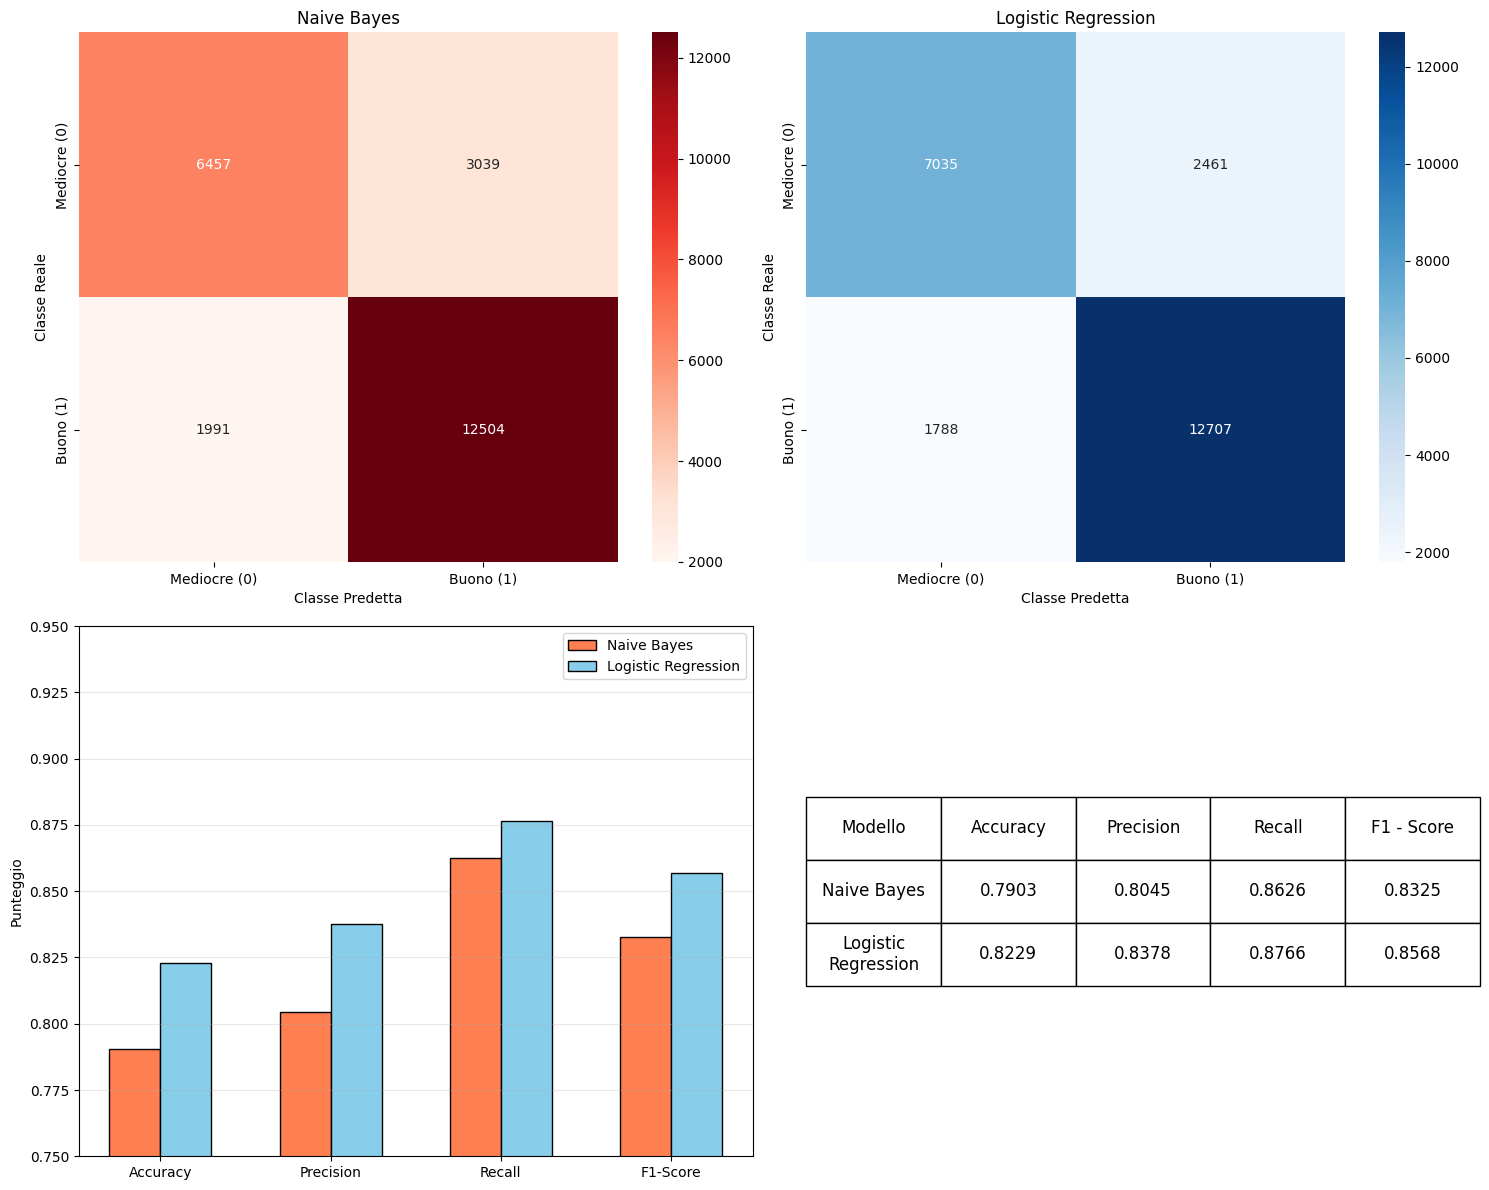

In [46]:
fig, axes = plt.subplots(2, 2, figsize = (15, 12))

#Etichette e posizioni 
labels = ["Mediocre (0)", "Buono (1)"] 
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.3 

#Confusion Matrix Naive Bayes
sns.heatmap(cm_nb, annot = True, fmt = "d", cmap = "Reds", xticklabels = labels, yticklabels = labels, ax = axes[0, 0])
axes[0, 0].set_title("Naive Bayes")
axes[0, 0].set_ylabel("Classe Reale")
axes[0, 0].set_xlabel("Classe Predetta")

#Confusion Matrix Logistic Regression
sns.heatmap(cm_lr, annot = True, fmt = "d", cmap = "Blues", xticklabels = labels, yticklabels = labels, ax = axes[0, 1])
axes[0, 1].set_title("Logistic Regression")
axes[0, 1].set_ylabel("Classe Reale")
axes[0, 1].set_xlabel("Classe Predetta")

#Metriche
axes[1, 0].bar(x - width / 2, nb_scores, width, label = "Naive Bayes", color = "coral", edgecolor = "black")
axes[1, 0].bar(x + width / 2, lr_scores, width, label = "Logistic Regression", color = "skyblue", edgecolor = "black")
axes[1, 0].set_ylabel("Punteggio")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_ylim([0.75, 0.95]) #Zoom
axes[1, 0].legend()
axes[1, 0].grid(axis = "y", alpha = 0.3)

#Tabella
table_data = [["Naive Bayes"] + [f"{s:.4f}" for s in nb_scores], ["Logistic\nRegression"] + [f"{s:.4f}" for s in lr_scores]]
axes[1, 1].axis("off")
table = axes[1, 1].table(cellText = table_data, colLabels = ["Modello", "Accuracy", "Precision", "Recall", "F1 - Score"], cellLoc = "center", loc = "center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3) #Zoom

plt.tight_layout()
plt.show()

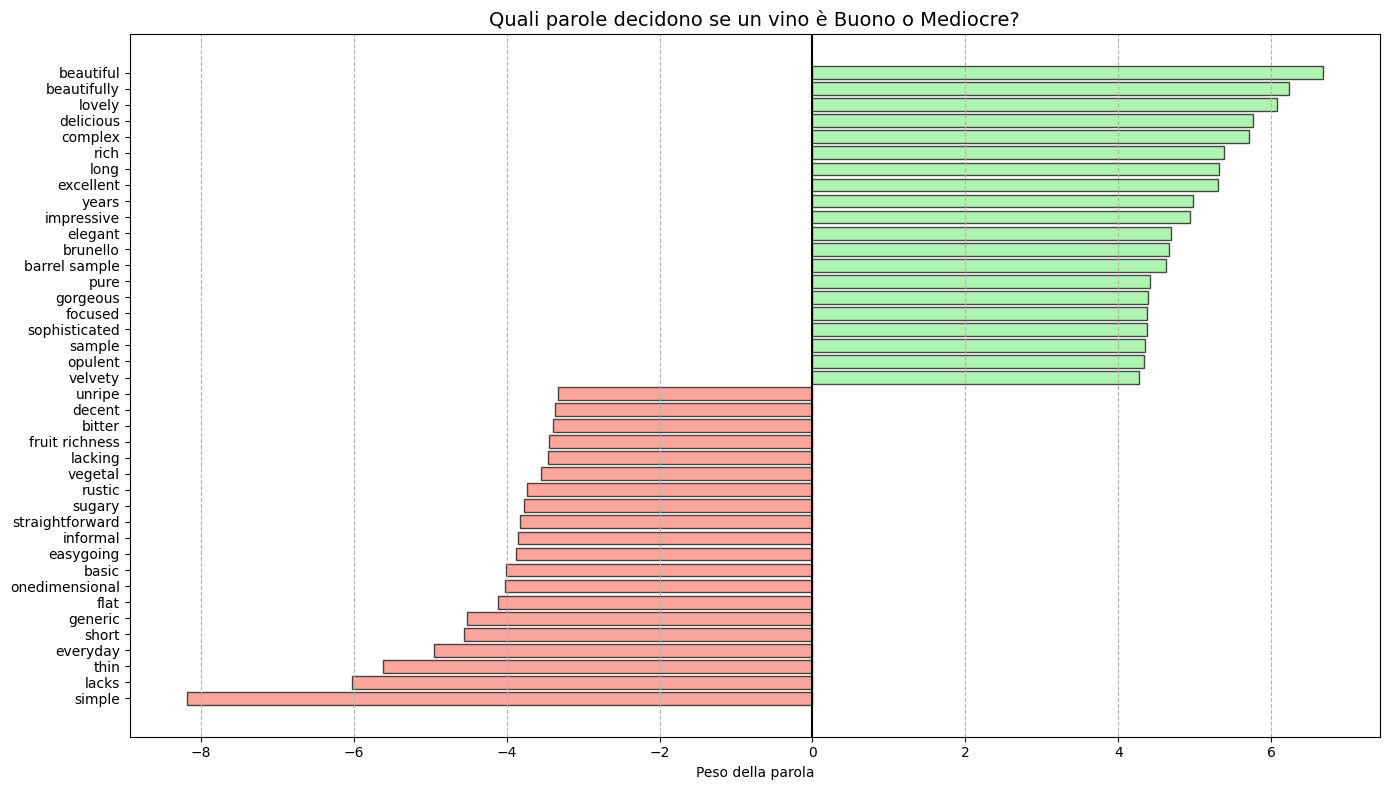

In [47]:
df_importance = pd.DataFrame({"Parola": tfidf.get_feature_names_out(), "Peso": lr_model.coef_[0]}) #Mappa ogni parola col suo coefficiente

df_plot = pd.concat([
    df_importance.nlargest(top_words, "Peso"), #Top positive
    df_importance.nsmallest(top_words, "Peso") #Top negative
]).sort_values(by = "Peso")

plt.figure(figsize = (14, 8))
colors = ["salmon" if x < 0 else "lightgreen" for x in df_plot["Peso"]]
plt.barh(df_plot["Parola"], df_plot["Peso"], color = colors, alpha = 0.7, edgecolor = "black")
plt.title("Quali parole decidono se un vino è Buono o Mediocre?", fontsize = 14)
plt.xlabel("Peso della parola")
plt.axvline(x = 0, color = "black") #Linea nera
plt.grid(axis = "x", linestyle = "--")

plt.tight_layout()
plt.show()

# ==============================================
# FASE 3: ANALISI PREDITTIVA SUI VINI SICILIANI
# ==============================================

In [51]:
print("--- PERFORMANCE SUI VINI SICILIANI ---")

#Filtra il DataFrame mantenendo solo quelle presenti nel Test Set e che sono siciliane
df_sicily_test = df.loc[X_test.index]
df_sicily_test = df_sicily_test[df_sicily_test["Is_Sicilian"] == 1]

print(f"\nVini Siciliani nel Test Set: {len(df_sicily_test)}")

if len(df_sicily_test) > 0:

    X_sicily = df_sicily_test["description_clean"] #Feature
    y_sicily_true = df_sicily_test["Sentiment"] #Target
    
    #Predizioni con LR
    y_sicily_pred_lr = lr_model.predict(tfidf.transform(X_sicily))

    #Metriche
    sicily_scores = [accuracy_score(y_sicily_true, y_sicily_pred_lr),
                     precision_score(y_sicily_true, y_sicily_pred_lr),
                     recall_score(y_sicily_true, y_sicily_pred_lr),
                     f1_score(y_sicily_true, y_sicily_pred_lr)]

    print(f"Accuracy:\t{sicily_scores[0]:.4f}")
    print(f"Precision:\t{sicily_scores[1]:.4f}")
    print(f"Recall:\t\t{sicily_scores[2]:.4f}")
    print(f"F1 - Score:\t{sicily_scores[3]:.4f}")

    print("\n--- ESEMPI DI CLASSIFICAZIONE ---")
    df_sicily_test["Pred_LR"] = y_sicily_pred_lr
    
    sample = df_sicily_test.sample(min(5, len(df_sicily_test)), random_state = my_number) #Prende e mostra un campione casuale di 5 vini
    
    for idx, row in sample.iterrows():
        esito = "✅" if row["Sentiment"] == row["Pred_LR"] else "❌"
        print(f"\n{esito} Vino: {row["title"]}")
        print(f"   Reale: {"Buono" if row["Sentiment"] == 1 else "Mediocre"} | Predetto: {"Buono" if row["Pred_LR"] == 1 else "Mediocre"}")
        print(f"   Recensione: \"{row["description"][:lenght]}...\"")

else: print("Nessun vino siciliano è finito nel test set.")

--- PERFORMANCE SUI VINI SICILIANI ---

Vini Siciliani nel Test Set: 331
Accuracy:	0.8157
Precision:	0.8000
Recall:		0.8686
F1 - Score:	0.8329

--- ESEMPI DI CLASSIFICAZIONE ---

❌ Vino: Sella & Mosca 2007 Riserva  (Cannonau di Sardegna)
   Reale: Mediocre | Predetto: Buono
   Recensione: "This opens with bright aromas of wild berry, white cherry, spice, cola and dried medicinal herb. It's a streamlined, elegant wine, with fresh acidity ..."

✅ Vino: Paolo Calì 2007 Manene  (Cerasuolo di Vittoria)
   Reale: Mediocre | Predetto: Mediocre
   Recensione: "Manene is a very attractive Cerasuolo di Vittoria (a blend of Nero d'Avola and Frappato) with loads of blueberry and wild berry followed by almond, co..."

✅ Vino: Planeta 2010 Merlot (Sicilia)
   Reale: Buono | Predetto: Buono
   Recensione: "This is round, soft and velvety, with notes of cherry, blackberry, spice, leather and tobacco. With no sharp edges, its acidity is well balanced withi..."

✅ Vino: MandraRossa 2015 Urra di Mare Sau

In [ ]:
print("--- TEST INTERATTIVO ---\n")

def analizza_recensione(testo):
    vec = tfidf.transform([preprocess_text(testo)]) #Pulisci e vettorizza il testo (transofrm vuole un iterable)
    prob = lr_model.predict_proba(vec).max() #Confidenza del modello
    tag = "✅ Buono" if lr_model.predict(vec)[0] == 1 else "❌ Mediocre"
    print(f"Recensione: \"{testo}\"\nEsito: {tag} (Sicurezza: {prob:.2%})\n")

analizza_recensione("This wine is absolutely amazing, full of complex flavors and elegant finish.")
analizza_recensione("Disgusting, it tastes like cheap vinegar and water. A waste of money.")
analizza_recensione("I expected more for this price, the aroma is weak and the taste is flat.")
analizza_recensione("This is a delicious review about rich wine, written only to see if words like flavour work very well on the model.")

--- TEST INTERATTIVO ---

Recensione: "This wine is absolutely amazing, full of complex flavors and elegant finish."
Esito: ✅ Buono (Sicurezza: 90.38%)

Recensione: "Disgusting, it tastes like cheap vinegar and water. A waste of money."
Esito: ❌ Mediocre (Sicurezza: 95.75%)

Recensione: "I expected more for this price, the aroma is weak and the taste is flat."
Esito: ❌ Mediocre (Sicurezza: 99.13%)

Recensione: "This is a delicious review about rich wine, written only to see if words like flavour work very well on the model."
Esito: ✅ Buono (Sicurezza: 67.87%)

